Saved: methodology_framework.png


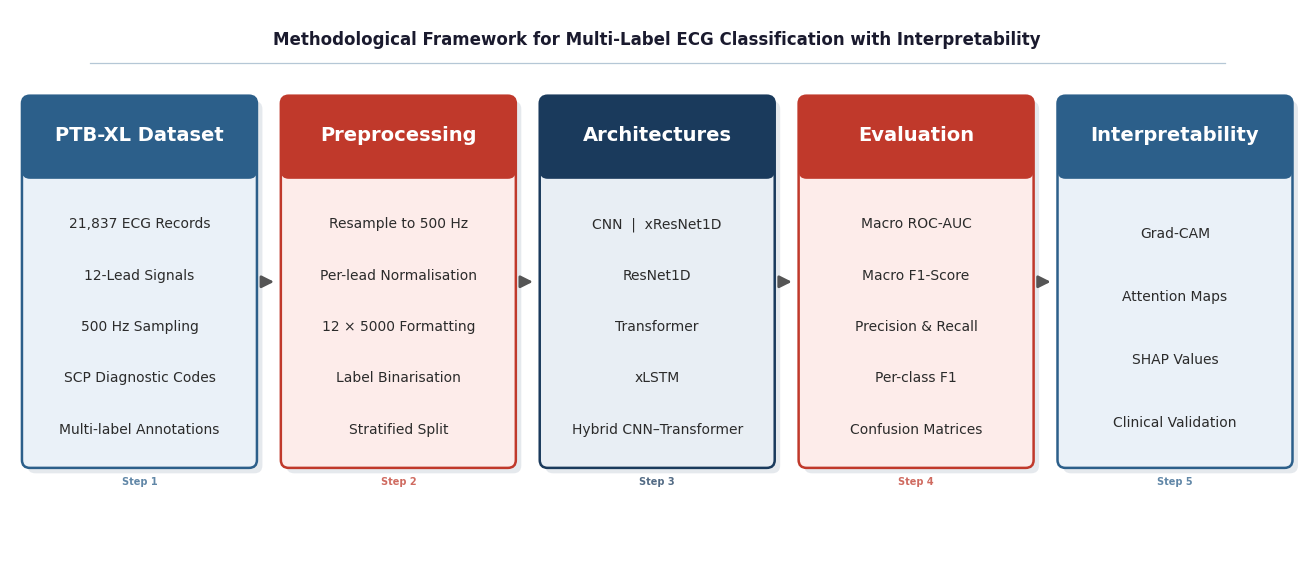

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.set_xlim(0, 13)
ax.set_ylim(0, 5.5)
ax.axis('off')
fig.patch.set_facecolor('#FFFFFF')

C_BLUE       = '#2C5F8A'
C_RED        = '#C0392B'
C_DARK       = '#1A3A5C'
C_LIGHT      = '#EAF1F8'
C_RED_LIGHT  = '#FDECEA'
C_DARK_LIGHT = '#E8EEF4'
C_SHADOW     = '#C0C8D4'
C_ARROW      = '#555555'

cols = [1.3, 3.9, 6.5, 9.1, 11.7]
cy   = 2.75
BW   = 2.2
BH   = 3.6

stages = [
    {
        'title': 'PTB-XL Dataset',
        'lines': ['21,837 ECG Records', '12-Lead Signals',
                  '500 Hz Sampling', 'SCP Diagnostic Codes',
                  'Multi-label Annotations'],
        'fc': C_LIGHT, 'ec': C_BLUE, 'tc': C_BLUE,
    },
    {
        'title': 'Preprocessing',
        'lines': ['Resample to 500 Hz', 'Per-lead Normalisation',
                  '12 × 5000 Formatting', 'Label Binarisation',
                  'Stratified Split'],
        'fc': C_RED_LIGHT, 'ec': C_RED, 'tc': C_RED,
    },
    {
        'title': 'Architectures',
        'lines': ['CNN  |  xResNet1D',
                  'ResNet1D',
                  'Transformer',
                  'xLSTM',
                  'Hybrid CNN–Transformer'],
        'fc': C_DARK_LIGHT, 'ec': C_DARK, 'tc': C_DARK,
    },
    {
        'title': 'Evaluation',
        'lines': ['Macro ROC-AUC', 'Macro F1-Score',
                  'Precision & Recall', 'Per-class F1',
                  'Confusion Matrices'],
        'fc': C_RED_LIGHT, 'ec': C_RED, 'tc': C_RED,
    },
    {
        'title': 'Interpretability',
        'lines': ['Grad-CAM', 'Attention Maps',
                  'SHAP Values',
                  'Clinical Validation'],
        'fc': C_LIGHT, 'ec': C_BLUE, 'tc': C_BLUE,
    },
]

def draw_box(ax, cx, cy, bw, bh, stage, step):
    x = cx - bw / 2
    y = cy - bh / 2

    # Shadow
    ax.add_patch(FancyBboxPatch(
        (x + 0.055, y - 0.055), bw, bh,
        boxstyle='round,pad=0.08',
        linewidth=0, facecolor=C_SHADOW, alpha=0.4, zorder=1
    ))

    # Main box
    ax.add_patch(FancyBboxPatch(
        (x, y), bw, bh,
        boxstyle='round,pad=0.08',
        linewidth=1.8, edgecolor=stage['ec'],
        facecolor=stage['fc'], zorder=2
    ))

    # Header strip
    ax.add_patch(FancyBboxPatch(
        (x, y + bh - 0.68), bw, 0.68,
        boxstyle='round,pad=0.08',
        linewidth=0, facecolor=stage['ec'], zorder=3
    ))

    # Title
    ax.text(cx, y + bh - 0.32, stage['title'],
            ha='center', va='center',
            fontsize=14, fontweight='bold',
            color='white', zorder=4)

    # Content lines
    n = len(stage['lines'])
    line_gap = (bh - 0.80) / (n + 0.4)
    for i, line in enumerate(stage['lines']):
        ly = y + bh - 0.80 - (i + 0.8) * line_gap
        ax.text(cx, ly, line,
                ha='center', va='center',
                fontsize=10, color='#2B2B2B', zorder=4)

    # Step tag bottom
    ax.text(cx, y - 0.22, f'Step {step}',
            ha='center', va='center',
            fontsize=7, color=stage['ec'],
            fontweight='bold', alpha=0.75, zorder=4)

def draw_arrow(ax, x1, x2, y):
    ax.annotate('',
                xy=(x2 - 0.12, y),
                xytext=(x1 + 0.12, y),
                arrowprops=dict(
                    arrowstyle='-|>',
                    linewidth=2.0,
                    color=C_ARROW,
                    mutation_scale=18,
                ), zorder=5)

# Draw all boxes
for i, (cx, stage) in enumerate(zip(cols, stages)):
    draw_box(ax, cx, cy, BW, BH, stage, i + 1)

# Draw arrows
for i in range(len(cols) - 1):
    draw_arrow(ax, cols[i] + BW/2, cols[i+1] - BW/2, cy)

# Title
ax.text(6.5, 5.2,
        'Methodological Framework for Multi-Label ECG Classification with Interpretability',
        ha='center', va='center',
        fontsize=12, fontweight='bold', color='#1A1A2E')

# Thin underline
ax.plot([0.8, 12.2], [4.96, 4.96], color=C_BLUE, linewidth=0.9, alpha=0.35)

plt.tight_layout(pad=0.2)
plt.savefig('methodology_framework.png', dpi=300,
            bbox_inches='tight', facecolor='white')
print('Saved: methodology_framework.png')
plt.show()